In [6]:
# ============================================================
# BLOCK 1 — CLEAN FAILED RUNS
#
# What this script does:
#   - Creates a cleaned copy of your rollout folder so the
#     original data stays untouched
#   - Optionally keeps only runs listed in an index CSV
#   - Removes rows marked as "failed"
#   - If a run ends in failure, keeps valid data before the
#     failure point and adds one final clean endpoint at the
#     target step so failed runs extend flat to the common
#     horizon — easier to compare across runs later
#
# Supports both FREEZE and LESION experiments via MODE config.
#
# Important:
#   - The original rollout folder is never edited
#   - All changes happen only in the cleaned output folder
# ============================================================

from __future__ import annotations

import csv
import os
import re
import shutil
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd


# =========================
# ======== CONFIG =========
# =========================

# Set to "freeze" or "lesion"
MODE = "freeze"

if MODE == "freeze":
    INPUT_PATH = Path(
        "/Users/adi/Downloads/AdaptionTesting4/Freeze_att71"
    ).expanduser()

    INDEX_CSV_PATH: Path | None = Path(
        "/Users/adi/Downloads/AdaptionTesting4/Freeze_att71/index_2026-04-03_20-28-36.csv"
    ).expanduser()

else:  # lesion
    INPUT_PATH = Path(
        "/Users/adi/Downloads/AdaptionTesting4/Lesion_att71"
    ).expanduser()

    INDEX_CSV_PATH = Path(
        "/Users/adi/Downloads/AdaptionTesting4/Lesion_att71/index_PLACEHOLDER.csv"
    ).expanduser()
    # INDEX_CSV_PATH = None

# -------------------------
# Row / quality config
# -------------------------
COUNT_HEADER_IN_ROW_THRESHOLD = True
MIN_ROWS_TO_KEEP              = 3
FAILED_TOKEN                  = "failed"
REMOVE_DUPLICATE_HEADERS      = True
MAX_ROWS_PER_CSV              = None

# -------------------------
# Cleaning horizon config
# -------------------------
# If CLEAN_TO_EXPLICIT_STEP is not None, failed runs are extended
# to this step in the cleaned copy.
CLEAN_TO_EXPLICIT_STEP: float | None = 500_000_000

# If CLEAN_TO_EXPLICIT_STEP is None, use the largest observed step
# across the cleaned set instead.
USE_GLOBAL_MAX_IF_NO_EXPLICIT_CLEAN_TARGET = True

# If True, failed runs that end early are extended flat to the
# common target horizon in the cleaned copy.
CLEAN_FAILED_RUNS_TO_TARGET = True

# If True, non-failed runs that end early are also extended.
# Usually False is better.
CLEAN_ALL_SHORT_RUNS_TO_TARGET = False


# =========================
# ======== HELPERS ========
# =========================

def resolve_rollout_dir(p: Path) -> Path:
    p = p.expanduser().resolve()
    return p.parent if p.is_file() else p


def row_contains_failed(row: list[str]) -> bool:
    token = FAILED_TOKEN.lower()
    return any(token in str(cell).lower() for cell in row if cell is not None)


def safe_read_csv_rows(csv_path: Path) -> list[list[str]]:
    with csv_path.open("r", newline="") as f:
        return [list(r) for r in csv.reader(f)]


def safe_write_csv_rows(csv_path: Path, rows: list[list[str]]) -> None:
    with csv_path.open("w", newline="") as f:
        csv.writer(f).writerows(rows)


def effective_row_count(rows: list[list[str]]) -> int:
    return len(rows) if COUNT_HEADER_IN_ROW_THRESHOLD else max(0, len(rows) - 1)


def run_name_from_rollout_path(p: Path) -> str:
    name = p.name
    if name.lower().endswith("__rollout_log.csv"):
        return name[: -len("__rollout_log.csv")]
    if name.lower().endswith(".csv"):
        return name[: -len(".csv")]
    return name


def load_index_allowlist(index_csv: Path) -> tuple[set[str], set[str]]:
    idx = pd.read_csv(index_csv, dtype=str)
    if "run_name" not in idx.columns:
        raise ValueError(f"Index CSV missing 'run_name' column: {index_csv}")
    allowed_run_names = set(idx["run_name"].dropna().astype(str).tolist())
    allowed_run_dir_basenames: set[str] = set()
    if "run_dir" in idx.columns:
        for rd in idx["run_dir"].dropna().astype(str):
            try:
                allowed_run_dir_basenames.add(Path(rd).name)
            except Exception:
                pass
    return allowed_run_names, allowed_run_dir_basenames


def try_float(x) -> float | None:
    try:
        s = str(x).strip()
        return float(s) if s else None
    except Exception:
        return None


def format_like(original: str, value: float) -> str:
    s = str(original).strip() if original else ""
    if not s:
        return str(int(round(value))) if float(value).is_integer() else str(value)
    if re.fullmatch(r"[-+]?\d+", s):
        return str(int(round(value)))
    if float(value).is_integer():
        return f"{value:.1f}" if ("." in s or "e" in s.lower()) else str(int(round(value)))
    return str(value)


def detect_step_columns_from_rows(rows: list[list[str]]) -> tuple[int | None, int | None]:
    if len(rows) <= 1:
        return None, None
    sample_n  = min(len(rows) - 1, 200)
    col1_vals = [try_float(r[1]) for r in rows[1: sample_n + 1] if len(r) > 1]
    col2_vals = [try_float(r[2]) for r in rows[1: sample_n + 1] if len(r) > 2]
    c1 = 1 if sum(v is not None for v in col1_vals) > 0 else None
    c2 = 2 if sum(v is not None for v in col2_vals) > 0 else None
    return c1, c2


def extract_last_valid_step_and_return(rows: list[list[str]]) -> tuple[float | None, float | None]:
    if len(rows) <= 1:
        return None, None
    c1, c2 = detect_step_columns_from_rows(rows)
    best_step, best_ret = None, None
    for r in rows[1:]:
        steps = [try_float(r[c]) for c in [c1, c2] if c is not None and len(r) > c]
        steps = [v for v in steps if v is not None]
        ret   = try_float(r[3]) if len(r) > 3 else None
        if not steps or ret is None:
            continue
        best_step = max(steps)
        best_ret  = ret
    return best_step, best_ret


def make_cleaned_endpoint_row(last_row: list[str], target_step: float) -> list[str]:
    new_row = list(last_row)
    if new_row and try_float(new_row[0]) is not None:
        new_row[0] = format_like(new_row[0], try_float(new_row[0]) + 1)
    for c in [1, 2]:
        if len(new_row) > c and try_float(new_row[c]) is not None:
            new_row[c] = format_like(new_row[c], target_step)
    return new_row


def remove_duplicate_headers(rows: list[list[str]]) -> tuple[list[list[str]], int]:
    if not REMOVE_DUPLICATE_HEADERS or len(rows) <= 1:
        return rows, 0
    header = rows[0]
    new_rows, removed = [header], 0
    for r in rows[1:]:
        if r == header:
            removed += 1
        else:
            new_rows.append(r)
    return new_rows, removed


def iter_csv_paths(root: Path) -> list[Path]:
    out: list[Path] = []
    for dirpath, _, filenames in os.walk(root):
        base = Path(dirpath)
        for name in filenames:
            if name.lower().endswith(".csv"):
                out.append(base / name)
    out.sort()
    return out


def get_target_clean_final_step(csv_paths: list[Path]) -> float | None:
    if CLEAN_TO_EXPLICIT_STEP is not None:
        return float(CLEAN_TO_EXPLICIT_STEP)
    if not USE_GLOBAL_MAX_IF_NO_EXPLICIT_CLEAN_TARGET:
        return None
    mx = None
    for p in csv_paths:
        try:
            arr = pd.read_csv(p, header=None, nrows=MAX_ROWS_PER_CSV)
        except Exception:
            continue
        if arr.shape[1] < 4:
            continue
        c1 = pd.to_numeric(arr.iloc[:, 1], errors="coerce")
        c2 = pd.to_numeric(arr.iloc[:, 2], errors="coerce")

        def score(s: pd.Series) -> float:
            s = s.dropna()
            if len(s) < 10:
                return -1e9
            return float((np.diff(s.to_numpy(float)) >= 0).mean()) * 1e6 + float(s.max())

        use  = c2 if score(c2) >= score(c1) else c1
        smax = pd.to_numeric(use, errors="coerce").dropna()
        if len(smax):
            cur = float(smax.max())
            mx  = cur if mx is None else max(mx, cur)
    return mx


def make_copy_ignore_func(
    src_root: Path,
    allowed_run_names: set[str] | None,
    allowed_run_dir_basenames: set[str] | None,
):
    use_filter = allowed_run_names is not None and allowed_run_dir_basenames is not None

    def _ignore(dirpath: str, names: list[str]) -> set[str]:
        if not use_filter:
            return set()
        ignored: set[str] = set()
        for name in names:
            full = Path(dirpath) / name
            if full.is_dir() or not name.lower().endswith(".csv"):
                continue
            if not (
                run_name_from_rollout_path(full) in allowed_run_names
                or full.parent.name in allowed_run_dir_basenames
            ):
                ignored.add(name)
        return ignored

    return _ignore


# =========================
# ========= CLEAN =========
# =========================

SRC_ROLLOUT_DIR = resolve_rollout_dir(INPUT_PATH)
if not SRC_ROLLOUT_DIR.exists():
    raise FileNotFoundError(f"Rollout folder not found: {SRC_ROLLOUT_DIR}")

timestamp       = datetime.now().strftime("%Y-%m-%d_%H-%M-%S")
DST_ROLLOUT_DIR = SRC_ROLLOUT_DIR.parent / f"{SRC_ROLLOUT_DIR.name}_cleaned_{timestamp}"

print(f"Mode:        {MODE.upper()}")
print(f"Source:      {SRC_ROLLOUT_DIR}")
print(f"Destination: {DST_ROLLOUT_DIR}")

allowed_run_names: set[str] | None         = None
allowed_run_dir_basenames: set[str] | None = None

if INDEX_CSV_PATH is not None:
    if not INDEX_CSV_PATH.exists():
        raise FileNotFoundError(f"INDEX_CSV_PATH not found: {INDEX_CSV_PATH}")
    allowed_run_names, allowed_run_dir_basenames = load_index_allowlist(INDEX_CSV_PATH)

copy_ignore = make_copy_ignore_func(SRC_ROLLOUT_DIR, allowed_run_names, allowed_run_dir_basenames)
shutil.copytree(SRC_ROLLOUT_DIR, DST_ROLLOUT_DIR, ignore=copy_ignore)
print("\n✅ Copied rollout folder.\n")

csv_paths = iter_csv_paths(DST_ROLLOUT_DIR)

if INDEX_CSV_PATH is not None:
    print("========== INDEX FILTER ==========")
    print(f"Index: {INDEX_CSV_PATH}")
    print("CSVs were filtered during copy.")
    print(f"CSVs after filter: {len(csv_paths)}")
    print("==================================\n")

TARGET_CLEAN_FINAL_STEP = get_target_clean_final_step(csv_paths)
print(f"Target final step for cleaning: {TARGET_CLEAN_FINAL_STEP}\n")

files_with_failed         = 0
total_failed_rows         = 0
files_modified            = 0
files_cleaned             = 0
failed_files_cleaned      = 0
rows_removed_total        = 0
failed_rows_removed_total = 0
dup_headers_removed_total = 0
short_files: list[Path]   = []

for p in csv_paths:
    try:
        rows = safe_read_csv_rows(p)
    except Exception as e:
        short_files.append(p)
        print(f"⚠️  Could not read {p}: {e}")
        continue

    if len(rows) == 0:
        short_files.append(p)
        continue

    rows, dup_removed = remove_duplicate_headers(rows)
    dup_headers_removed_total += dup_removed

    failed_row_idxs = [i for i, r in enumerate(rows) if row_contains_failed(r)]
    has_failed       = len(failed_row_idxs) > 0

    if has_failed:
        files_with_failed += 1
        total_failed_rows += len(failed_row_idxs)

    header = rows[0:1]
    body   = rows[1:] if len(rows) > 1 else []

    if has_failed:
        first_failed_idx = failed_row_idxs[0]
        kept_rows = [
            r for i, r in enumerate(rows[1:], start=1)
            if i < first_failed_idx and not row_contains_failed(r)
        ]
        failed_rows_removed_total += len(failed_row_idxs)
    else:
        kept_rows = [r for r in body if not row_contains_failed(r)]

    new_rows = header + kept_rows

    should_clean = False
    if TARGET_CLEAN_FINAL_STEP is not None and len(new_rows) >= 2:
        last_step, _ = extract_last_valid_step_and_return(new_rows)
        if last_step is not None and last_step < TARGET_CLEAN_FINAL_STEP:
            if has_failed and CLEAN_FAILED_RUNS_TO_TARGET:
                should_clean = True
            elif (not has_failed) and CLEAN_ALL_SHORT_RUNS_TO_TARGET:
                should_clean = True

        if should_clean:
            new_rows.append(make_cleaned_endpoint_row(new_rows[-1], TARGET_CLEAN_FINAL_STEP))
            files_cleaned += 1
            if has_failed:
                failed_files_cleaned += 1

    if new_rows != rows:
        rows_removed_total += max(0, len(rows) - len(new_rows))
        safe_write_csv_rows(p, new_rows)
        files_modified += 1

    if effective_row_count(new_rows) < MIN_ROWS_TO_KEEP:
        short_files.append(p)

print("========== PRE-CLEAN COUNTS ==========")
print(f"Total CSV files:                {len(csv_paths)}")
print(f"CSV files containing 'failed':  {files_with_failed}")
print(f"Total 'failed' rows (all CSVs): {total_failed_rows}")
print("======================================\n")

print("========== CLEANING SUMMARY ==========")
print(f"Files modified (rewritten):            {files_modified}")
print(f"Rows removed total:                    {rows_removed_total}")
print(f"Failed rows removed:                   {failed_rows_removed_total}")
print(f"Duplicate header rows removed:         {dup_headers_removed_total}")
print(f"Files cleaned to target horizon:       {files_cleaned}")
print(f"  of which failed-run files:           {failed_files_cleaned}")
print("======================================\n")

print("========== POST-CLEAN SHORT FILES ==========")
print(
    f"Row threshold (< {MIN_ROWS_TO_KEEP}) "
    f"with COUNT_HEADER_IN_ROW_THRESHOLD={COUNT_HEADER_IN_ROW_THRESHOLD}"
)
print(f"Files to delete: {len(short_files)}")
print("============================================\n")

deleted = 0
for p in short_files:
    try:
        if p.exists():
            p.unlink()
            deleted += 1
    except Exception as e:
        print(f"⚠️  Could not delete {p}: {e}")

print("========== DELETE SUMMARY ==========")
print(f"Deleted files: {deleted}")
print("=====================================\n")

print("Done.")
print(f"Cleaned rollout folder: {DST_ROLLOUT_DIR}")

Mode:        FREEZE
Source:      /Users/adi/Downloads/AdaptionTesting4/Freeze_att71
Destination: /Users/adi/Downloads/AdaptionTesting4/Freeze_att71_cleaned_2026-04-21_17-01-16

✅ Copied rollout folder.

========== INDEX FILTER ==========
Index: /Users/adi/Downloads/AdaptionTesting4/Freeze_att71/index_2026-04-03_20-28-36.csv
CSVs were filtered during copy.
CSVs after filter: 2376

Target final step for cleaning: 500000000.0

========== PRE-CLEAN COUNTS ==========
Total CSV files:                2376
CSV files containing 'failed':  394
Total 'failed' rows (all CSVs): 788

========== CLEANING SUMMARY ==========
Files modified (rewritten):            394
Rows removed total:                    394
Failed rows removed:                   788
Duplicate header rows removed:         0
Files cleaned to target horizon:       394
  of which failed-run files:           394

========== POST-CLEAN SHORT FILES ==========
Row threshold (< 3) with COUNT_HEADER_IN_ROW_THRESHOLD=True
Files to delete: 0

==

Mode: FREEZE
Loaded 1188 runs  (594 self-freeze,  594 task-freeze)


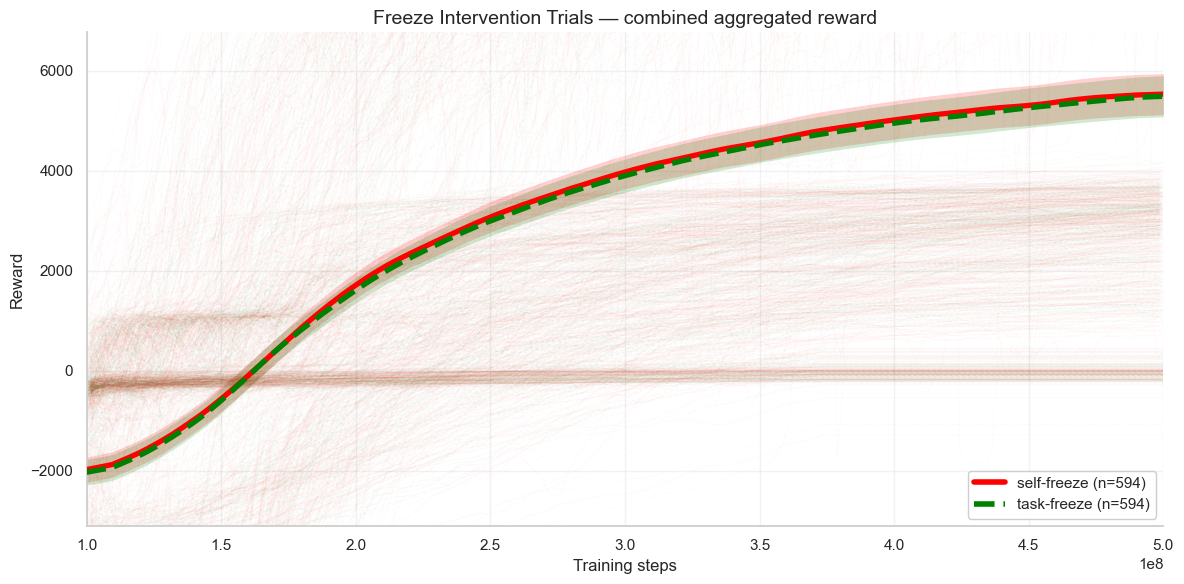


PAIR MATCHING
  Matched pairs  : 594
  Unmatched self : 0
  Unmatched task: 0

HORIZONTAL COMPARISON — backward scan, no extrapolation
  Tied threshold: |self_end - task_end| <= 1.0

  Total pairs        : 594
  Ties (excluded)    : 2  (|diff| <= 1.0)
  self-freeze won : 317
  task-freeze won: 275
  Used in stats      : 592

  Horizontal advantage of self-freeze over task-freeze:
    Mean   +1.9%
    Median +1.6%
    Positive in 53.5% of non-tied pairs
    Bootstrap confidence : 92.7%
    Wilcoxon p           = 0.0618
    One-sided t-test p   = 0.0713

  Per-transition breakdown:
    walk→spin: mean=+0.9%  median=+1.5%  n_used=99  self_won=52  task_won=47  ties=0  frac>0=53%
    walk→jump: mean=+7.1%  median=+9.3%  n_used=99  self_won=58  task_won=41  ties=0  frac>0=59%
    spin→walk: mean=+1.7%  median=+2.4%  n_used=99  self_won=56  task_won=43  ties=0  frac>0=57%
    spin→jump: mean=-0.4%  median=+1.3%  n_used=99  self_won=51  task_won=48  ties=0  frac>0=52%
    jump→walk: mean=+0.3

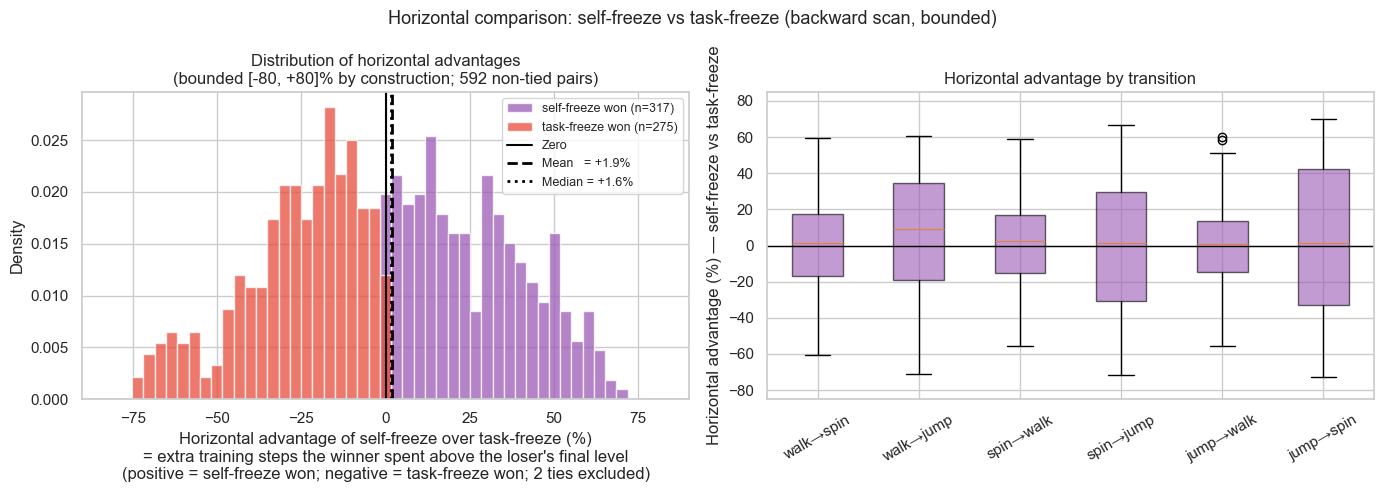

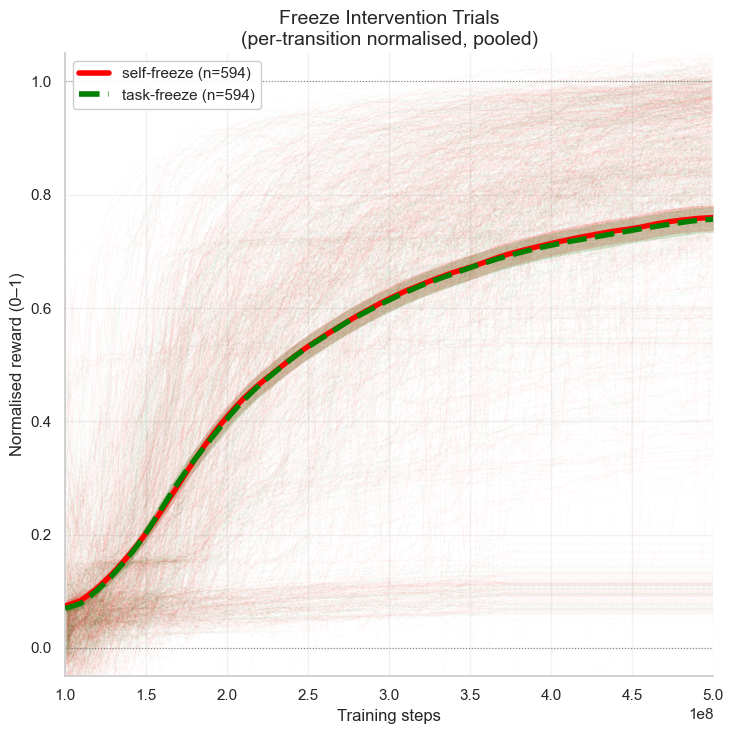


FINAL SUMMARY — FREEZE MODE

  Horizontal comparison:
    Total pairs        : 594
    Ties excluded      : 2  (|diff| <= 1.0)
    self-freeze won  : 317
    task-freeze won : 275

    Mean   advantage : +1.9%
    Median advantage : +1.6%
    Positive in      : 53.5% of non-tied pairs
    Wilcoxon p       = 0.0618
    Bootstrap conf.  = 92.7%

  PAPER-READY SENTENCE:
  In matched pairwise comparisons (n=592 non-tied pairs), self-freeze showed a median horizontal advantage of 2% (2% mean) — measured as the fraction of total training spent above the partner condition's final reward level (54% of pairs positive, Wilcoxon p = 0.0618, bootstrap confidence 92.7%). 2 pairs were excluded as ties (|reward difference| <= 1.0).


In [8]:
# ============================================================
# BLOCK 2 — TRANSITION ANALYSIS
#           SELF-FREEZE vs TASK-FREEZE  /  SELF-LESION vs TASK-LESION
#
# Sections:
#   1.  Aggregated reward curve with 95% CI (raw units)
#   2.  Pair matching
#   3.  Horizontal comparison — clean backward-scan method
#   4.  Normalised aggregate reward plot (0–1, per-transition)
#   5.  Final summary + paper-ready sentence
#
# ── Horizontal comparison method ───────────────────────────
#
#   For each matched pair:
#
#   1. Find self reward at X_MAX and task reward at X_MAX.
#
#   2. If |self_end - task_end| <= TIED_THRESHOLD:
#        pair is a tie → excluded from statistics, counted separately.
#
#   3. Otherwise, identify WINNER (higher at X_MAX) and
#      LOSER (lower at X_MAX).
#
#   4. Take LOSER's final reward level → y_loser_end.
#
#   5. Scan WINNER's curve backwards from X_MAX to find the
#      last step where WINNER was at or below y_loser_end.
#      Call that step  t_back.
#
#   6. horizontal_advantage_steps = X_MAX - t_back
#      horizontal_advantage_pct   = advantage_steps / X_MAX * 100
#
#      This is the number of extra training steps WINNER had
#      above the loser's final level.
#
#   7. Sign:
#        self > task  →  positive advantage for self-freeze
#        task > self  →  negative advantage (task-freeze won)
#
#   No extrapolation. No division by slopes. Bounded by definition
#   to [0%, 80%] in absolute value.
# ============================================================

from __future__ import annotations

import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as sp_stats
from matplotlib.lines import Line2D

sns.set_theme(style="whitegrid")


# ============================================================
# ==================== MASTER CONFIG =========================
# ============================================================

MODE = "freeze"   # "freeze" or "lesion"

if MODE == "freeze":
    ROOT_DIR = Path(
        "/Users/adi/Downloads/AdaptionTesting4/Freeze_att71_cleaned_2026-04-21_16-36-17"
    ).expanduser().resolve()
else:
    ROOT_DIR = Path(
        "/Users/adi/Downloads/AdaptionTesting4/Lesion_att71_cleaned_PLACEHOLDER"
    ).expanduser().resolve()

TRANSITIONS_TO_INCLUDE = [
    "walk→spin",
    "walk→jump",
    "spin→walk",
    "spin→jump",
    "jump→walk",
    "jump→spin",
]

SELF_COND  = "self"
TASK_COND  = "task"
CONDITIONS = [SELF_COND, TASK_COND]

if MODE == "freeze":
    PRIMARY_COND     = SELF_COND
    REFERENCE_COND   = TASK_COND
    PRIMARY_LABEL    = "self-freeze"
    REFERENCE_LABEL  = "task-freeze"
    EXPERIMENT_TITLE = "Freeze Intervention Trials"
else:
    PRIMARY_COND     = TASK_COND
    REFERENCE_COND   = SELF_COND
    PRIMARY_LABEL    = "task-lesion"
    REFERENCE_LABEL  = "self-lesion"
    EXPERIMENT_TITLE = "Lesion Intervention Trials"

X_MIN = 1e8
X_MAX = 5e8

# Pairs where |self_end - task_end| <= this are treated as ties
# and excluded from the horizontal analysis statistics.
TIED_THRESHOLD = 1.0

MAX_ROWS_PER_CSV = None
N_GRID           = 500
SMOOTH_WINDOW    = 25
SHOW_FAINT_RUNS  = True
FAINT_ALPHA      = 0.018
FAINT_LW         = 0.8
MEAN_LW          = 3.8
CI_ALPHA         = 0.18

COND_COLOR = {SELF_COND: "red", TASK_COND: "green"}

N_BOOT    = 20_000
RAND_SEED = 42

AUTO_FOCUS_Y = True
Y_PAD_FRAC   = 0.10
Y_PAD_MIN    = 0.05


# ============================================================
# =================== FILENAME PARSER ========================
# ============================================================
FNAME_RE = re.compile(
    r"""
    ^(?P<prefix>.+?)__
    run(?P<runid>\d+)__
    (?P<src_cycle>c\d+)_(?P<src_behavior>walk|jump|spin)__
    (?P<condition>[^_]+?)__
    to_(?P<dst_behavior>walk|jump|spin)__
    seed(?P<seed>\d+)__
    rollout_log\.csv$
    """,
    re.VERBOSE | re.IGNORECASE,
)


def parse_rollout_filename(p: Path) -> dict | None:
    m = FNAME_RE.match(p.name)
    if not m:
        return None
    d = m.groupdict()
    d["runid"]            = f"run{int(d['runid']):02d}"
    d["src_cycle"]        = d["src_cycle"].lower()
    d["src_behavior"]     = d["src_behavior"].lower()
    d["dst_behavior"]     = d["dst_behavior"].lower()
    d["condition"]        = d["condition"].lower()
    d["transition_label"] = f"{d['src_behavior']}→{d['dst_behavior']}"
    d["seed"]             = int(d["seed"])
    d["path"]             = str(p.resolve())
    return d


# ============================================================
# ====================== CSV READER ==========================
# ============================================================
_rollout_cache: dict[str, pd.DataFrame] = {}


def read_rollout_csv(path: str) -> pd.DataFrame:
    arr = pd.read_csv(path, header=None, nrows=MAX_ROWS_PER_CSV)
    c1  = pd.to_numeric(arr.iloc[:, 1], errors="coerce")
    c2  = pd.to_numeric(arr.iloc[:, 2], errors="coerce")
    ret = pd.to_numeric(arr.iloc[:, 3], errors="coerce")

    def score(s: pd.Series) -> float:
        s = s.dropna()
        if len(s) < 10:
            return -1e9
        return float((np.diff(s.to_numpy(float)) >= 0).mean()) * 1e6 + float(s.max())

    use_steps = c2 if score(c2) >= score(c1) else c1
    df = pd.DataFrame({"steps": use_steps, "return": ret}).dropna()
    df = df.sort_values("steps").drop_duplicates(subset=["steps"], keep="last")
    return df.reset_index(drop=True)


def get_rollout(path: str) -> pd.DataFrame:
    if path not in _rollout_cache:
        _rollout_cache[path] = read_rollout_csv(path)
    return _rollout_cache[path]


def crop_df(df: pd.DataFrame) -> pd.DataFrame:
    return df[(df["steps"] >= X_MIN) & (df["steps"] <= X_MAX)].copy().reset_index(drop=True)


# ============================================================
# =================== PLOTTING HELPERS =======================
# ============================================================

def smooth_series(y: np.ndarray, window: int) -> np.ndarray:
    if window <= 1:
        return y
    return (
        pd.Series(y)
        .rolling(window=window, min_periods=max(3, window // 3), center=True)
        .mean()
        .to_numpy()
    )


def crop_runs_to_aggregate_window(runs):
    valid = [r for r in runs if len(r) >= 2]
    if not valid:
        return [], None, None
    x_lo = max(min(float(r["steps"].min()) for r in valid), X_MIN)
    x_hi = min(max(float(r["steps"].max()) for r in valid), X_MAX)
    if x_hi <= x_lo:
        return [], None, None
    cropped = [r[(r["steps"] >= x_lo) & (r["steps"] <= x_hi)].copy() for r in valid]
    return [r for r in cropped if len(r) >= 2], x_lo, x_hi


def interpolate_group(runs, n_grid=400):
    if not runs:
        return None, None
    x_lo = max(min(float(r["steps"].min()) for r in runs if len(r) >= 2), X_MIN)
    x_hi = min(max(float(r["steps"].max()) for r in runs if len(r) >= 2), X_MAX)
    if x_hi <= x_lo:
        return None, None
    xgrid = np.linspace(x_lo, x_hi, n_grid)
    Y     = np.full((len(runs), n_grid), np.nan)
    for i, r in enumerate(runs):
        if len(r) < 2:
            continue
        Y[i] = np.interp(xgrid, r["steps"].to_numpy(float), r["return"].to_numpy(float))
    return xgrid, Y


def compute_mean_and_ci95(Y):
    mean  = np.nanmean(Y, axis=0)
    n_eff = np.sum(np.isfinite(Y), axis=0)
    std   = np.nanstd(Y, axis=0, ddof=1)
    sem   = np.where(n_eff > 1, std / np.sqrt(n_eff), np.nan)
    return mean, 1.96 * sem, n_eff


def focused_ylim(curves):
    if not curves:
        return None
    vals = np.concatenate([
        np.concatenate([(m - c)[np.isfinite(m - c)], (m + c)[np.isfinite(m + c)]])
        for m, c in curves
    ])
    if not len(vals):
        return None
    lo, hi = float(np.min(vals)), float(np.max(vals))
    if not (np.isfinite(lo) and np.isfinite(hi)):
        return None
    span = max(hi - lo, 1.0)
    pad  = max(Y_PAD_MIN, Y_PAD_FRAC * span)
    return lo - pad, hi + pad


# ============================================================
# =================== STATISTICAL HELPERS ====================
# ============================================================

def bootstrap_conf(diffs, n_boot=N_BOOT, seed=RAND_SEED):
    rng = np.random.default_rng(seed)
    return 100.0 * float(
        np.mean(diffs[rng.integers(0, len(diffs), (n_boot, len(diffs)))].mean(1) > 0)
    )


def paired_tests(diffs):
    diffs = diffs[np.isfinite(diffs)]
    if len(diffs) < 3:
        return None
    t_stat, t_p = sp_stats.ttest_1samp(diffs, 0)
    try:
        _, w_p = sp_stats.wilcoxon(diffs, alternative="greater")
    except Exception:
        w_p = np.nan
    n_pos = int(np.sum(diffs > 0))
    n_nz  = int(np.sum(diffs != 0))
    return {
        "n_pairs"            : len(diffs),
        "mean_diff"          : float(np.mean(diffs)),
        "median_diff"        : float(np.median(diffs)),
        "frac_positive"      : float(np.mean(diffs > 0)),
        "boot_confidence_pct": bootstrap_conf(diffs),
        "ttest_p_onesided"   : float(t_p / 2) if t_stat > 0 else 1.0 - float(t_p / 2),
        "wilcoxon_p"         : float(w_p),
        "sign_p"             : float(
            sp_stats.binomtest(n_pos, n_nz, 0.5, alternative="greater").pvalue
        ) if n_nz > 0 else np.nan,
    }


# ============================================================
# ==================== LOAD DATA =============================
# ============================================================
if not ROOT_DIR.exists():
    raise FileNotFoundError(f"ROOT_DIR not found: {ROOT_DIR}")

meta_rows = [parse_rollout_filename(p) for p in sorted(ROOT_DIR.rglob("*.csv"))]
meta_rows = [d for d in meta_rows if d is not None]
if not meta_rows:
    raise RuntimeError(f"No matching rollout CSVs found in {ROOT_DIR}")

meta     = pd.DataFrame(meta_rows)
meta_sel = meta[
    meta["transition_label"].isin(TRANSITIONS_TO_INCLUDE)
    & meta["condition"].isin(CONDITIONS)
].copy()
if meta_sel.empty:
    raise RuntimeError("No runs left after filtering.")

COND_LABEL = {PRIMARY_COND: PRIMARY_LABEL, REFERENCE_COND: REFERENCE_LABEL}

print(
    f"Mode: {MODE.upper()}\n"
    f"Loaded {len(meta_sel)} runs  "
    f"({(meta_sel['condition'] == PRIMARY_COND).sum()} {PRIMARY_LABEL},  "
    f"{(meta_sel['condition'] == REFERENCE_COND).sum()} {REFERENCE_LABEL})"
)

runs_by_condition: dict[str, list[pd.DataFrame]] = {c: [] for c in CONDITIONS}
runs_with_trans:   dict[str, list[tuple[str, pd.DataFrame]]] = {c: [] for c in CONDITIONS}

for _, row in meta_sel.iterrows():
    raw  = crop_df(get_rollout(row["path"]))
    if len(raw) < 2:
        continue
    cond = row["condition"]
    runs_by_condition[cond].append(raw)
    runs_with_trans[cond].append((row["transition_label"], raw))


# ============================================================
# SECTION 1: AGGREGATED REWARD CURVE (raw units)
# ============================================================
fig, ax = plt.subplots(figsize=(12, 6))
sns.despine(ax=ax)
ax.grid(True, alpha=0.25)

leg_h, leg_l, agg_curves = [], [], []

for cond in [PRIMARY_COND, REFERENCE_COND]:
    runs  = runs_by_condition[cond]
    color = COND_COLOR[cond]
    ls    = "-" if cond == PRIMARY_COND else "--"

    runs_plot, _, _ = crop_runs_to_aggregate_window(runs)
    if not runs_plot:
        continue

    if SHOW_FAINT_RUNS:
        for r in runs_plot:
            ax.plot(r["steps"], r["return"],
                    color=color, alpha=FAINT_ALPHA, lw=FAINT_LW, ls=ls, zorder=1)

    xgrid, Y = interpolate_group(runs_plot, N_GRID)
    if xgrid is None:
        continue

    mean, ci95, _ = compute_mean_and_ci95(Y)
    ms = smooth_series(mean, SMOOTH_WINDOW)
    cs = smooth_series(ci95, SMOOTH_WINDOW)
    agg_curves.append((ms, cs))

    ax.plot(xgrid, ms, color=color, lw=MEAN_LW, ls=ls, zorder=3)
    ax.fill_between(xgrid, ms - cs, ms + cs,
                    color=color, alpha=CI_ALPHA, lw=0, zorder=2)

    leg_h.append(Line2D([0], [0], color=color, lw=4, ls=ls))
    leg_l.append(f"{COND_LABEL[cond]} (n={len(runs_plot)})")

ax.set_xlim(X_MIN, X_MAX)
ax.set_xlabel("Training steps")
ax.set_ylabel("Reward")
ax.set_title(f"{EXPERIMENT_TITLE} — combined aggregated reward", fontsize=14)
if AUTO_FOCUS_Y:
    yl = focused_ylim(agg_curves)
    if yl:
        ax.set_ylim(*yl)
ax.legend(handles=leg_h, labels=leg_l, loc="best", frameon=True, framealpha=0.95, fontsize=11)
plt.tight_layout()
plt.show()


# ============================================================
# SECTION 2: PAIR MATCHING
# ============================================================
print("\n" + "=" * 70)
print("PAIR MATCHING")
print("=" * 70)

keyed = []
for _, row in meta_sel.iterrows():
    raw = crop_df(get_rollout(row["path"]))
    if len(raw) < 2:
        continue
    keyed.append({
        "transition": row["transition_label"],
        "condition" : row["condition"],
        "seed"      : row["seed"],
        "runid"     : row["runid"],
        "src_cycle" : row["src_cycle"],
        "run_df"    : raw,
    })

keyed_df  = pd.DataFrame(keyed)
pair_keys = ["transition", "seed", "runid", "src_cycle"]

prim_df = keyed_df[keyed_df["condition"] == PRIMARY_COND].copy()
ref_df  = keyed_df[keyed_df["condition"] == REFERENCE_COND].copy()
paired  = prim_df.merge(ref_df, on=pair_keys, suffixes=("_prim", "_ref"), how="inner")

print(f"  Matched pairs  : {len(paired)}")
print(f"  Unmatched {PRIMARY_LABEL[:4]} : {len(prim_df) - len(paired)}")
print(f"  Unmatched {REFERENCE_LABEL[:4]}: {len(ref_df)  - len(paired)}")

trans_col = "transition_prim" if "transition_prim" in paired.columns else "transition"


# ============================================================
# SECTION 3: HORIZONTAL COMPARISON — backward scan
#
# For each pair:
#   1. Interpolate self_end and task_end at X_MAX.
#   2. If |self_end - task_end| <= TIED_THRESHOLD → tie, skip.
#   3. WINNER = whichever ended higher; LOSER = the other.
#   4. Scan WINNER's curve backwards from X_MAX to find the last
#      step where WINNER was at or below LOSER's final level.
#      Call that step t_back.
#   5. advantage_steps = X_MAX - t_back
#      advantage_pct   = advantage_steps / X_MAX * 100
#      This is always in [0, 80]% by construction.
#   6. Sign: positive if PRIMARY (self/task) was the winner,
#            negative if REFERENCE was the winner.
# ============================================================
print("\n" + "=" * 70)
print("HORIZONTAL COMPARISON — backward scan, no extrapolation")
print(f"  Tied threshold: |self_end - task_end| <= {TIED_THRESHOLD}")
print("=" * 70)


def backward_scan_steps(winner_df: pd.DataFrame, loser_end: float) -> float:
    """
    Scan the winner's curve backwards from X_MAX to find the last step
    where the winner was at or below loser_end.
    Returns the number of extra steps the winner spent above loser_end.
    Always in [0, X_MAX - X_MIN].
    """
    x = winner_df["steps"].to_numpy(float)
    y = winner_df["return"].to_numpy(float)

    # Dense grid across the window
    mask  = (x >= X_MIN) & (x <= X_MAX)
    x_seg = np.concatenate([[X_MIN], x[mask], [X_MAX]])
    y_seg = np.interp(x_seg, x, y)
    _, ui = np.unique(x_seg, return_index=True)
    x_seg = x_seg[ui]
    y_seg = y_seg[ui]

    # Scan backwards for the last crossing (winner drops to loser_end)
    for i in range(len(x_seg) - 1, 0, -1):
        if y_seg[i - 1] <= loser_end <= y_seg[i]:
            # Interpolate the crossing point
            frac = (loser_end - y_seg[i - 1]) / (y_seg[i] - y_seg[i - 1])
            t_cross = x_seg[i - 1] + frac * (x_seg[i] - x_seg[i - 1])
            return float(X_MAX - t_cross)

    # Winner was above loser_end the entire window → full window advantage
    if y_seg[0] > loser_end:
        return float(X_MAX - X_MIN)

    # Winner never reached loser_end (shouldn't happen since winner > loser
    # at X_MAX, but guard anyway)
    return 0.0


horiz_rows = []
for _, pr in paired.iterrows():
    prim_x = pr["run_df_prim"]["steps"].to_numpy(float)
    prim_y = pr["run_df_prim"]["return"].to_numpy(float)
    ref_x  = pr["run_df_ref"]["steps"].to_numpy(float)
    ref_y  = pr["run_df_ref"]["return"].to_numpy(float)

    self_end = float(np.interp(X_MAX, prim_x, prim_y))
    task_end = float(np.interp(X_MAX, ref_x,  ref_y))

    diff = self_end - task_end

    if abs(diff) <= TIED_THRESHOLD:
        horiz_rows.append({
            "transition"   : pr[trans_col],
            "horiz_adv_pct": np.nan,
            "case"         : "tie",
            "winner"       : "tie",
        })
        continue

    if diff > 0:
        # self-freeze won
        adv_steps = backward_scan_steps(pr["run_df_prim"], task_end)
        sign      = 1.0
        winner    = PRIMARY_LABEL
    else:
        # task-freeze won
        adv_steps = backward_scan_steps(pr["run_df_ref"], self_end)
        sign      = -1.0
        winner    = REFERENCE_LABEL

    adv_pct = sign * 100.0 * adv_steps / X_MAX

    horiz_rows.append({
        "transition"   : pr[trans_col],
        "horiz_adv_pct": adv_pct,
        "case"         : "primary_won" if sign > 0 else "reference_won",
        "winner"       : winner,
    })

horiz_df    = pd.DataFrame(horiz_rows)
n_total     = len(horiz_df)
n_ties      = int((horiz_df["case"] == "tie").sum())
n_prim_won  = int((horiz_df["case"] == "primary_won").sum())
n_ref_won   = int((horiz_df["case"] == "reference_won").sum())

# Statistics on non-tied pairs only
valid_adv = horiz_df["horiz_adv_pct"].dropna().to_numpy(float)
res = paired_tests(valid_adv)

print(f"\n  Total pairs        : {n_total}")
print(f"  Ties (excluded)    : {n_ties}  (|diff| <= {TIED_THRESHOLD})")
print(f"  {PRIMARY_LABEL} won : {n_prim_won}")
print(f"  {REFERENCE_LABEL} won: {n_ref_won}")
print(f"  Used in stats      : {len(valid_adv)}")

print(f"\n  Horizontal advantage of {PRIMARY_LABEL} over {REFERENCE_LABEL}:")
print(f"    Mean   {res['mean_diff']:+.1f}%")
print(f"    Median {res['median_diff']:+.1f}%")
print(f"    Positive in {100*res['frac_positive']:.1f}% of non-tied pairs")
print(f"    Bootstrap confidence : {res['boot_confidence_pct']:.1f}%")
print(f"    Wilcoxon p           = {res['wilcoxon_p']:.4f}")
print(f"    One-sided t-test p   = {res['ttest_p_onesided']:.4f}")

print("\n  Per-transition breakdown:")
trans_horiz_data: dict[str, np.ndarray] = {}
for t in TRANSITIONS_TO_INCLUDE:
    sub   = horiz_df[horiz_df["transition"] == t]
    valid = sub["horiz_adv_pct"].dropna().to_numpy(float)
    n_t   = int((sub["case"] == "tie").sum())
    n_pw  = int((sub["case"] == "primary_won").sum())
    n_rw  = int((sub["case"] == "reference_won").sum())
    if not len(valid):
        continue
    trans_horiz_data[t] = valid
    print(f"    {t}: mean={valid.mean():+.1f}%  median={np.median(valid):+.1f}%  "
          f"n_used={len(valid)}  {PRIMARY_LABEL[:4]}_won={n_pw}  "
          f"{REFERENCE_LABEL[:4]}_won={n_rw}  ties={n_t}  "
          f"frac>0={100*(valid>0).mean():.0f}%")

# ---- Plots ----
pos_vals = valid_adv[valid_adv >= 0]
neg_vals = valid_adv[valid_adv <  0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
bins = np.linspace(-82, 82, 50)
if len(pos_vals):
    ax.hist(pos_vals, bins=bins, color="#9b59b6", alpha=0.75, density=True,
            label=f"{PRIMARY_LABEL} won (n={n_prim_won})")
if len(neg_vals):
    ax.hist(neg_vals, bins=bins, color="#e74c3c", alpha=0.75, density=True,
            label=f"{REFERENCE_LABEL} won (n={n_ref_won})")

ax.axvline(0, color="black", lw=1.5, label="Zero")
ax.axvline(res["mean_diff"],   color="black", lw=2, ls="--",
           label=f"Mean   = {res['mean_diff']:+.1f}%")
ax.axvline(res["median_diff"], color="black", lw=2, ls=":",
           label=f"Median = {res['median_diff']:+.1f}%")
ax.set_xlabel(
    f"Horizontal advantage of {PRIMARY_LABEL} over {REFERENCE_LABEL} (%)\n"
    f"= extra training steps the winner spent above the loser's final level\n"
    f"(positive = {PRIMARY_LABEL} won; negative = {REFERENCE_LABEL} won; "
    f"{n_ties} ties excluded)"
)
ax.set_ylabel("Density")
ax.set_title(f"Distribution of horizontal advantages\n"
             f"(bounded [{'-80'}, +80]% by construction; {len(valid_adv)} non-tied pairs)")
ax.legend(fontsize=9)

ax = axes[1]
if trans_horiz_data:
    labels = list(trans_horiz_data.keys())
    data   = [trans_horiz_data[l] for l in labels]
    bp     = ax.boxplot(data, tick_labels=labels, patch_artist=True)
    for i, patch in enumerate(bp["boxes"]):
        patch.set_facecolor("#9b59b6" if np.median(data[i]) > 0 else "#e74c3c")
        patch.set_alpha(0.6)
    ax.axhline(0, color="black", lw=1)
    ax.set_ylim(-85, 85)
    ax.set_ylabel(f"Horizontal advantage (%) — {PRIMARY_LABEL} vs {REFERENCE_LABEL}")
    ax.set_title("Horizontal advantage by transition")
    ax.tick_params(axis="x", rotation=30)

fig.suptitle(
    f"Horizontal comparison: {PRIMARY_LABEL} vs {REFERENCE_LABEL} "
    f"(backward scan, bounded)",
    fontsize=13,
)
plt.tight_layout()
plt.show()


# ============================================================
# SECTION 4: NORMALISED AGGREGATE REWARD PLOT (0–1)
# ============================================================

trans_bounds: dict[str, tuple[float, float]] = {}
for trans in TRANSITIONS_TO_INCLUDE:
    all_r = []
    for cond in CONDITIONS:
        for t_label, df in runs_with_trans[cond]:
            if t_label == trans:
                vals = df["return"].to_numpy(float)
                all_r.extend(vals[np.isfinite(vals)].tolist())
    if not all_r:
        continue
    arr = np.array(all_r, dtype=float)
    trans_bounds[trans] = (
        float(np.percentile(arr, 1)),
        float(np.percentile(arr, 99)),
    )


def norm_by_trans(df: pd.DataFrame, trans: str) -> pd.DataFrame | None:
    if trans not in trans_bounds:
        return None
    lo, hi = trans_bounds[trans]
    span   = max(hi - lo, 1e-9)
    out    = df.copy()
    out["return"] = (out["return"] - lo) / span
    return out


fig_n, ax_n = plt.subplots(figsize=(7.5, 7.5))
sns.despine(ax=ax_n)
ax_n.grid(True, alpha=0.25)

leg_hn, leg_ln = [], []

for cond in [PRIMARY_COND, REFERENCE_COND]:
    norm_runs = []
    for trans, df in runs_with_trans[cond]:
        nd = norm_by_trans(df, trans)
        if nd is not None and len(nd) >= 2:
            norm_runs.append(nd)

    color = COND_COLOR[cond]
    ls    = "-" if cond == PRIMARY_COND else "--"
    label = COND_LABEL[cond]

    runs_plot, _, _ = crop_runs_to_aggregate_window(norm_runs)
    if not runs_plot:
        continue

    if SHOW_FAINT_RUNS:
        for r in runs_plot:
            ax_n.plot(r["steps"], r["return"],
                      color=color, alpha=FAINT_ALPHA, lw=FAINT_LW, ls=ls, zorder=1)

    xgrid, Y = interpolate_group(runs_plot, N_GRID)
    if xgrid is None:
        continue

    mean, ci95, _ = compute_mean_and_ci95(Y)
    ms = smooth_series(mean, SMOOTH_WINDOW)
    cs = smooth_series(ci95, SMOOTH_WINDOW)

    ax_n.plot(xgrid, ms, color=color, lw=MEAN_LW, ls=ls, zorder=3)
    ax_n.fill_between(xgrid, ms - cs, ms + cs,
                      color=color, alpha=CI_ALPHA, lw=0, zorder=2)

    leg_hn.append(Line2D([0], [0], color=color, lw=4, ls=ls))
    leg_ln.append(f"{label} (n={len(runs_plot)})")

ax_n.set_xlim(X_MIN, X_MAX)
ax_n.set_ylim(-0.05, 1.05)
ax_n.axhline(0, color="gray", lw=0.8, ls=":")
ax_n.axhline(1, color="gray", lw=0.8, ls=":")
ax_n.set_xlabel("Training steps")
ax_n.set_ylabel("Normalised reward (0–1)")
ax_n.set_title(
    f"{EXPERIMENT_TITLE}\n(per-transition normalised, pooled)",
    fontsize=14,
)
if leg_hn:
    ax_n.legend(handles=leg_hn, labels=leg_ln,
                loc="best", frameon=True, framealpha=0.95, fontsize=11)
plt.tight_layout()
plt.show()


# ============================================================
# SECTION 5: FINAL SUMMARY + PAPER-READY SENTENCE
# ============================================================
print("\n" + "=" * 70)
print(f"FINAL SUMMARY — {MODE.upper()} MODE")
print("=" * 70)

print(
    f"\n  Horizontal comparison:\n"
    f"    Total pairs        : {n_total}\n"
    f"    Ties excluded      : {n_ties}  (|diff| <= {TIED_THRESHOLD})\n"
    f"    {PRIMARY_LABEL} won  : {n_prim_won}\n"
    f"    {REFERENCE_LABEL} won : {n_ref_won}\n"
    f"\n    Mean   advantage : {res['mean_diff']:+.1f}%\n"
    f"    Median advantage : {res['median_diff']:+.1f}%\n"
    f"    Positive in      : {100*res['frac_positive']:.1f}% of non-tied pairs\n"
    f"    Wilcoxon p       = {res['wilcoxon_p']:.4f}\n"
    f"    Bootstrap conf.  = {res['boot_confidence_pct']:.1f}%"
)

print(
    f"\n  PAPER-READY SENTENCE:\n"
    f"  In matched pairwise comparisons (n={len(valid_adv)} non-tied pairs), "
    f"{PRIMARY_LABEL} showed a median horizontal advantage of "
    f"{res['median_diff']:.0f}% ({res['mean_diff']:.0f}% mean) — "
    f"measured as the fraction of total training spent above the "
    f"partner condition's final reward level "
    f"({100*res['frac_positive']:.0f}% of pairs positive, "
    f"Wilcoxon p = {res['wilcoxon_p']:.4f}, "
    f"bootstrap confidence {res['boot_confidence_pct']:.1f}%). "
    f"{n_ties} pairs were excluded as ties "
    f"(|reward difference| <= {TIED_THRESHOLD})."
)

print("=" * 70)

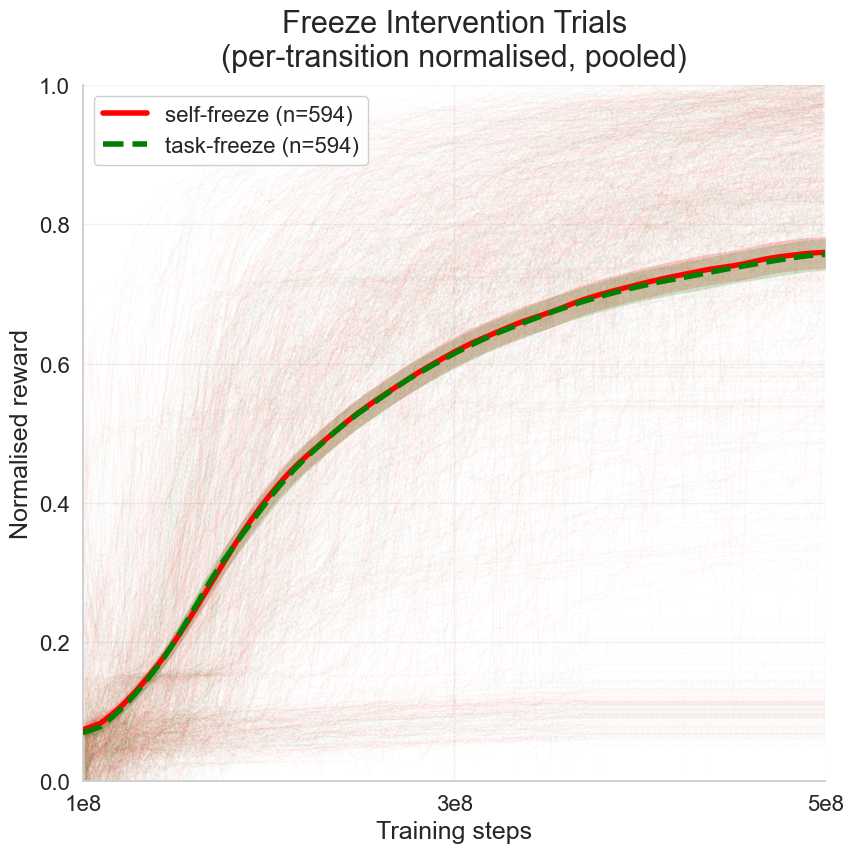

In [7]:
# ============================================================
# PAPER-READY SQUARE NORMALISED PLOT ONLY
# Compatible with old freeze / lesion scripts
#
# Behavior:
# - If plotting freeze conditions, do NOT show the original curves.
# - If plotting lesion conditions, also pull ORIGINAL curves from lesion trials.
# - Bigger text.
# - Hard crop y-axis to [0, 1].
# ============================================================

import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib.ticker import FixedLocator, FuncFormatter

# ============================================================
# USER SETTINGS
# ============================================================
LESION_DIR = Path(
    "/Users/adi/Downloads/AdaptionTesting4/Baseline_Lesions_Reinit_BD_corrected3_cleaned_2026-04-21_20-31-12"
).expanduser().resolve()

TITLE_FS   = 22
LABEL_FS   = 18
TICK_FS    = 16
LEGEND_FS  = 16

SHOW_FAINT_RUNS = globals().get("SHOW_FAINT_RUNS", True)
FAINT_ALPHA     = globals().get("FAINT_ALPHA", 0.018)
FAINT_LW        = globals().get("FAINT_LW", 0.8)
MEAN_LW         = globals().get("MEAN_LW", 4.2)
CI_ALPHA        = globals().get("CI_ALPHA", 0.18)
SMOOTH_WINDOW   = globals().get("SMOOTH_WINDOW", 25)
N_GRID          = globals().get("N_GRID", 500)

# ============================================================
# REQUIRED CHECKS
# ============================================================
if "X_MIN" not in globals() or "X_MAX" not in globals():
    raise NameError("X_MIN and/or X_MAX are not defined. Run the main analysis block first.")

# ============================================================
# HELPERS
# ============================================================
def _smooth_series(y: np.ndarray, window: int) -> np.ndarray:
    if window <= 1:
        return y
    return (
        pd.Series(y)
        .rolling(window=window, min_periods=max(3, window // 3), center=True)
        .mean()
        .to_numpy()
    )

def _crop_runs_to_aggregate_window(runs):
    valid = [r for r in runs if len(r) >= 2]
    if not valid:
        return [], None, None
    x_lo = max(min(float(r["steps"].min()) for r in valid), X_MIN)
    x_hi = min(max(float(r["steps"].max()) for r in valid), X_MAX)
    if x_hi <= x_lo:
        return [], None, None
    cropped = [r[(r["steps"] >= x_lo) & (r["steps"] <= x_hi)].copy() for r in valid]
    return [r for r in cropped if len(r) >= 2], x_lo, x_hi

def _interpolate_group(runs, n_grid=400):
    if not runs:
        return None, None
    x_lo = max(min(float(r["steps"].min()) for r in runs if len(r) >= 2), X_MIN)
    x_hi = min(max(float(r["steps"].max()) for r in runs if len(r) >= 2), X_MAX)
    if x_hi <= x_lo:
        return None, None
    xgrid = np.linspace(x_lo, x_hi, n_grid)
    Y = np.full((len(runs), n_grid), np.nan)
    for i, r in enumerate(runs):
        if len(r) < 2:
            continue
        Y[i] = np.interp(xgrid, r["steps"].to_numpy(float), r["return"].to_numpy(float))
    return xgrid, Y

def _compute_mean_and_ci95(Y):
    mean  = np.nanmean(Y, axis=0)
    n_eff = np.sum(np.isfinite(Y), axis=0)
    std   = np.nanstd(Y, axis=0, ddof=1)
    sem   = np.where(n_eff > 1, std / np.sqrt(n_eff), np.nan)
    return mean, 1.96 * sem, n_eff

def _norm_by_trans(df: pd.DataFrame, trans: str, trans_bounds: dict):
    if trans not in trans_bounds:
        return None
    lo, hi = trans_bounds[trans]
    span = max(hi - lo, 1e-9)
    out = df.copy()
    out["return"] = (out["return"] - lo) / span
    return out

def _read_rollout_csv(path: str) -> pd.DataFrame:
    arr = pd.read_csv(path, header=None)
    c1  = pd.to_numeric(arr.iloc[:, 1], errors="coerce")
    c2  = pd.to_numeric(arr.iloc[:, 2], errors="coerce")
    ret = pd.to_numeric(arr.iloc[:, 3], errors="coerce")

    def _score(s: pd.Series) -> float:
        s = s.dropna()
        if len(s) < 10:
            return -1e9
        return float((np.diff(s.to_numpy(float)) >= 0).mean()) * 1e6 + float(s.max())

    use_steps = c2 if _score(c2) >= _score(c1) else c1
    df = pd.DataFrame({"steps": use_steps, "return": ret}).dropna()
    df = df.sort_values("steps").drop_duplicates(subset=["steps"], keep="last")
    return df.reset_index(drop=True)

def _crop_df(df: pd.DataFrame) -> pd.DataFrame:
    return df[(df["steps"] >= X_MIN) & (df["steps"] <= X_MAX)].copy().reset_index(drop=True)

FNAME_RE_LESION = re.compile(
    r"""
    ^(?P<prefix>.+?)__
    run(?P<runid>\d+)__
    (?P<src_cycle>c\d+)_(?P<src_behavior>walk|jump|spin)__
    (?P<condition>[^_]+?)__
    (?P<src_behavior_2>walk|jump|spin)_to_(?P<dst_behavior>walk|jump|spin)__
    seed(?P<seed>\d+)__
    rollout_log\.csv$
    """,
    re.VERBOSE | re.IGNORECASE,
)

def _parse_lesion_filename(p: Path):
    m = FNAME_RE_LESION.match(p.name)
    if m is None:
        return None
    d = m.groupdict()
    d["runid"]         = f"run{int(d['runid']):02d}"
    d["src_cycle"]     = d["src_cycle"].lower()
    d["src_behavior"]  = d["src_behavior"].lower()
    d["dst_behavior"]  = d["dst_behavior"].lower()
    d["condition"]     = d["condition"].lower()
    d["seed"]          = int(d["seed"])
    d["path"]          = str(p.resolve())
    d["transition"]    = f"{d['src_behavior']}→{d['dst_behavior']}"
    if d.get("src_behavior_2", "").lower() != d["src_behavior"]:
        return None
    return d

# ============================================================
# START FROM EXISTING runs_with_trans IF PRESENT
# ============================================================
if "runs_with_trans" not in globals():
    raise NameError("runs_with_trans is not defined. Run the main analysis block first.")

plot_data = {}
for cond, items in runs_with_trans.items():
    clean_items = []
    for trans, df in items:
        if isinstance(df, pd.DataFrame) and len(df) >= 2:
            clean_items.append((trans, df.copy()))
    if clean_items:
        plot_data[cond] = clean_items

if not plot_data:
    raise RuntimeError("No usable runs found in runs_with_trans.")

existing_order = list(plot_data.keys())

# ============================================================
# DETECT MODE
# ============================================================
is_lesion_plot = any(c in ["selflesion", "tasklesion"] for c in existing_order)
is_freeze_plot = any(c in ["self", "task"] for c in existing_order)

# ============================================================
# ONLY ADD ORIGINAL FOR LESION PLOTS
# ============================================================
if is_lesion_plot:
    if not LESION_DIR.exists():
        raise FileNotFoundError(f"Lesion directory not found: {LESION_DIR}")

    lesion_original = []
    for p in sorted(LESION_DIR.rglob("*.csv")):
        meta = _parse_lesion_filename(p)
        if meta is None:
            continue
        if meta["condition"] != "original":
            continue
        df = _crop_df(_read_rollout_csv(meta["path"]))
        if len(df) < 2:
            continue
        lesion_original.append((meta["transition"], df))

    if lesion_original:
        plot_data["original"] = lesion_original

# ============================================================
# CONDITION ORDER / LABELS / COLORS
# ============================================================
existing_order = list(plot_data.keys())

primary_guess   = globals().get("PRIMARY_COND", existing_order[0])
reference_guess = globals().get("REFERENCE_COND", existing_order[1] if len(existing_order) > 1 else existing_order[0])

plot_order = []
for c in [primary_guess, reference_guess]:
    if c in plot_data and c not in plot_order:
        plot_order.append(c)

# only include original in lesion mode
if is_lesion_plot and "original" in plot_data:
    plot_order.append("original")

for c in existing_order:
    if c not in plot_order and c != "original":
        plot_order.append(c)

default_label_map = {
    "self": "self-freeze",
    "task": "task-freeze",
    "selflesion": "self-lesion",
    "tasklesion": "task-lesion",
    "original": "original",
}
default_color_map = {
    "self": "red",
    "task": "green",
    "selflesion": "red",
    "tasklesion": "green",
    "original": "black",
}

COND_LABEL = globals().get("COND_LABEL", {}).copy() if "COND_LABEL" in globals() else {}
COND_COLOR = globals().get("COND_COLOR", {}).copy() if "COND_COLOR" in globals() else {}

fallback_colors = ["red", "green", "black", "blue", "purple", "orange", "brown"]
for i, c in enumerate(plot_order):
    if c not in COND_LABEL:
        COND_LABEL[c] = default_label_map.get(c, c)
    if c not in COND_COLOR:
        COND_COLOR[c] = default_color_map.get(c, fallback_colors[i % len(fallback_colors)])

EXPERIMENT_TITLE = globals().get("EXPERIMENT_TITLE", "Intervention Trials")

line_styles = {}
if len(plot_order) >= 1:
    line_styles[plot_order[0]] = "-"
if len(plot_order) >= 2:
    line_styles[plot_order[1]] = "--"
if "original" in plot_order:
    line_styles["original"] = ":"
for c in plot_order:
    if c not in line_styles:
        line_styles[c] = "-."

# ============================================================
# BUILD TRANSITION NORMALISATION BOUNDS
# ============================================================
all_transitions = sorted({
    trans
    for cond in plot_order
    for trans, _ in plot_data.get(cond, [])
})

if not all_transitions:
    raise RuntimeError("No transitions found to plot.")

trans_bounds = {}
for trans in all_transitions:
    all_r = []
    for cond in plot_order:
        for t_label, df in plot_data.get(cond, []):
            if t_label == trans:
                vals = df["return"].to_numpy(float)
                all_r.extend(vals[np.isfinite(vals)].tolist())
    if not all_r:
        continue
    arr = np.array(all_r, dtype=float)
    trans_bounds[trans] = (
        float(np.percentile(arr, 1)),
        float(np.percentile(arr, 99)),
    )

if not trans_bounds:
    raise RuntimeError("Could not compute per-transition normalisation bounds.")

# ============================================================
# PLOT
# ============================================================
fig_n, ax_n = plt.subplots(figsize=(8.7, 8.7))
sns.despine(ax=ax_n)
ax_n.grid(True, alpha=0.25)

leg_hn, leg_ln = [], []

for cond in plot_order:
    norm_runs = []
    for trans, df in plot_data.get(cond, []):
        nd = _norm_by_trans(df, trans, trans_bounds)
        if nd is not None and len(nd) >= 2:
            norm_runs.append(nd)

    if not norm_runs:
        continue

    color = COND_COLOR[cond]
    ls    = line_styles[cond]
    label = COND_LABEL[cond]

    runs_plot, _, _ = _crop_runs_to_aggregate_window(norm_runs)
    if not runs_plot:
        continue

    if SHOW_FAINT_RUNS:
        for r in runs_plot:
            ax_n.plot(
                r["steps"], r["return"],
                color=color, alpha=FAINT_ALPHA, lw=FAINT_LW, ls=ls, zorder=1
            )

    xgrid, Y = _interpolate_group(runs_plot, N_GRID)
    if xgrid is None:
        continue

    mean, ci95, _ = _compute_mean_and_ci95(Y)
    ms = _smooth_series(mean, SMOOTH_WINDOW)
    cs = _smooth_series(ci95, SMOOTH_WINDOW)

    ax_n.plot(xgrid, ms, color=color, lw=MEAN_LW, ls=ls, zorder=3)
    ax_n.fill_between(
        xgrid,
        ms - cs,
        ms + cs,
        color=color,
        alpha=CI_ALPHA,
        lw=0,
        zorder=2
    )

    leg_hn.append(Line2D([0], [0], color=color, lw=4, ls=ls))
    leg_ln.append(f"{label} (n={len(runs_plot)})")

ax_n.set_xlim(X_MIN, X_MAX)
ax_n.set_ylim(0.0, 1.0)

ax_n.set_xlabel("Training steps", fontsize=LABEL_FS)
ax_n.set_ylabel("Normalised reward", fontsize=LABEL_FS)
ax_n.set_title(
    f"{EXPERIMENT_TITLE}\n(per-transition normalised, pooled)",
    fontsize=TITLE_FS,
    pad=14,
)

xticks = [1e8, 3e8, 5e8]
ax_n.xaxis.set_major_locator(FixedLocator(xticks))
ax_n.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(x/1e8)}e8"))

ax_n.tick_params(axis="both", labelsize=TICK_FS)

if leg_hn:
    ax_n.legend(
        handles=leg_hn,
        labels=leg_ln,
        loc="best",
        frameon=True,
        framealpha=0.95,
        fontsize=LEGEND_FS
    )

plt.tight_layout()
plt.show()